In [290]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.random import default_rng

In [291]:
class DataFrameGenerator:
    def __init__(self, n_samples=100, seed=42):
        self.n_samples = n_samples
        self.rng = default_rng(seed)

        self.produto_codes = ["11234", "22345", "33456", "44567"]
        self.atraso_categories = [
            "1-15",
            "16-30",
            "31-45",
            "46-60",
            "61-90",
            "91-120",
            "120+",
        ]
        self.target_categories = ["atraso", "av", "ap", "cessao", None]

        # Probabilities (must sum to 1.0)
        self.target_probs = [0.5, 0.3, 0.1, 0.05, 0.05]  # 70% atraso, 10% av, etc.
        self.produto_probs = [0.25, 0.35, 0.10, 0.30]

        # Precompute possible dates
        self.dates = (
            pd.date_range(start="2024-01-01", end="2024-12-31")
            .strftime("%Y%m%d")
            .tolist()
        )

    def generate_dates(self):
        indices = self.rng.integers(0, len(self.dates), size=self.n_samples)
        return [self.dates[i] for i in indices]

    def generate_produto(self):
        return self.rng.choice(
            self.produto_codes, size=self.n_samples, p=self.produto_probs
        )

    def generate_atraso(self):
        return self.rng.choice(self.atraso_categories, size=self.n_samples)

    def generate_target(self):
        return self.rng.choice(
            self.target_categories, size=self.n_samples, p=self.target_probs
        )

    def generate_dataframe(self):
        df = pd.DataFrame(
            {
                "anomesdia": self.generate_dates(),
                "produto": self.generate_produto(),
                "atraso": self.generate_atraso(),
                "target": self.generate_target(),
            }
        )
        return df

In [292]:
def generate_grouping_sets(df: pd.DataFrame, target_col: str = "target") -> dict:
    """
    Generate groupings based on predefined sets of columns, along with counts of occurrences.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataframe with the necessary columns (`anomesdia`, `produto`, `atraso`, `target`, etc.).
    target_col : str, optional
        The name of the target column. Default is 'target'.

    Returns
    -------
    dict
        A dictionary with each key being a grouping combination and its corresponding DataFrame of counts.
    """
    # Grouping sets as per your specification
    groupings = {
        "target": [target_col],
        "anomesdia_target": ["anomesdia", target_col],
        "atraso_target": ["atraso", target_col],
        "produto_target": ["produto", target_col],
        "anomesdia_atraso_target": ["anomesdia", "atraso", target_col],
        "produto_atraso_target": ["produto", "atraso", target_col],
        "anomesdia_produto_atraso_target": [
            "anomesdia",
            "produto",
            "atraso",
            target_col,
        ],
    }

    grouped_dfs = {}

    # For each grouping, perform the aggregation and store in the dictionary
    for key, group_cols in groupings.items():
        # Aggregate counts using size() to count rows for each group
        df_grouped = (
            df.groupby(group_cols, observed=False).size().reset_index(name="count")
        )
        grouped_dfs[key] = df_grouped

    return grouped_dfs

In [293]:
def regroup(
    df: pd.DataFrame, group_cols: list, count_col: str = "count"
) -> pd.DataFrame:
    """
    Regroup a full-set grouped DataFrame into a subset grouping.

    Parameters:
    - df (pd.DataFrame): The full-set grouped DataFrame.
    - group_cols (list): The list of columns to group by.
    - count_col (str): The name of the count column (default is 'count').

    Returns:
    - pd.DataFrame: A new DataFrame grouped by group_cols with summed counts.
    """

    df_copy = df.copy()
    return df_copy.groupby(group_cols, as_index=False, observed=False)[count_col].sum()

In [294]:
def prop(
    df: pd.DataFrame,
    count_col: str = "count",
    prop_col: str = "prop",
    group_cols: list = None,
) -> pd.DataFrame:
    """
    Calculate the proportion of counts, automatically guessing sensible groupings, and log what it does.
    This version ensures the input DataFrame is copied, preventing modification of the original DataFrame.

    Parameters:
    - df (pd.DataFrame): The grouped DataFrame.
    - count_col (str): The name of the count column (default is 'count').
    - prop_col (str): The name of the new proportion column.
    - group_cols (list or None): Optional. If None, automatically guesses group columns.

    Returns:
    - pd.DataFrame: The same DataFrame with a new proportion column.
    """
    df = df.copy()  # Ensure the original df is not modified

    # Auto-detect group_cols if not provided
    if group_cols is None:
        possible_group_cols = [
            "anomesdia",
            "produto",
            "atraso",
        ]
        group_cols = [col for col in possible_group_cols if col in df.columns]

        if group_cols:
            print(f"[INFO] Grouping by: {group_cols}")
        else:
            print(
                "[INFO] No grouping columns found. Calculating proportion over the entire DataFrame."
            )
            group_cols = []

    else:
        print(f"[INFO] Using manual grouping: {group_cols}")

    if group_cols:
        # Calculate total per group
        total_per_group = df.groupby(group_cols, observed=False)[count_col].transform(
            "sum"
        )
    else:
        # No grouping: total across all
        total_per_group = df[count_col].sum()

    # Calculate proportion
    df[prop_col] = df[count_col] / total_per_group

    return df


In [ ]:
def lower_bound(range_str):
    if "+" in range_str:
        return int(range_str.split("+")[0])  # For "150+", return 150
    else:
        return int(range_str.split("-")[0])  # For "1-15", return 1

In [256]:
# Example

generator = DataFrameGenerator(n_samples=1000000, seed=42)
df = generator.generate_dataframe()
df["anomesdia"] = pd.to_datetime(df["anomesdia"], format="%Y%m%d")

grouping_dfs = generate_grouping_sets(df)

In [295]:
df_all = grouping_dfs["anomesdia_produto_atraso_target"]
df_all["count"] = df_all["count"] / 10e3  # Normalize the count

# Set "atraso" column as a categorical variable with the custom sorting
df_all["atraso"] = pd.Categorical(
    df_all["atraso"],
    categories=sorted(df_all["atraso"].unique(), key=lambda x: lower_bound(x)),
    ordered=True,
)

df_cleaned = df_all.copy()
df_cleaned = df_all[df_all["target"].isin(["av", "ap", "atraso"])]

mapping = {"av": "av+ap", "ap": "av+ap"}
df_binary = df_cleaned.copy()
df_binary["target"] = df_binary["target"].map(mapping).fillna(df_binary["target"])

[INFO] No grouping columns found. Calculating proportion over the entire DataFrame.


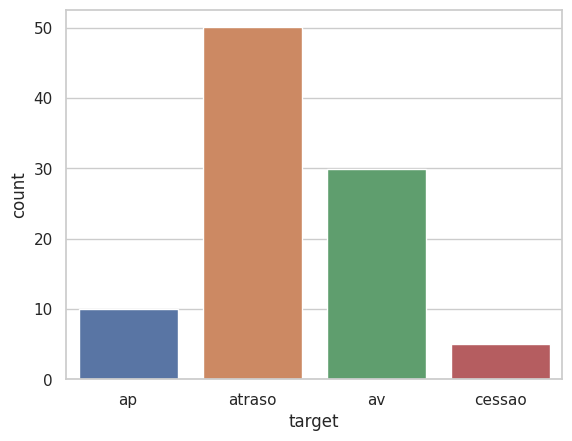

In [ ]:
df_target = prop(regroup(df_all, group_cols=["target"]))
sns.barplot(df_target, x="target", y="count", hue="target")
plt.show()

[INFO] No grouping columns found. Calculating proportion over the entire DataFrame.


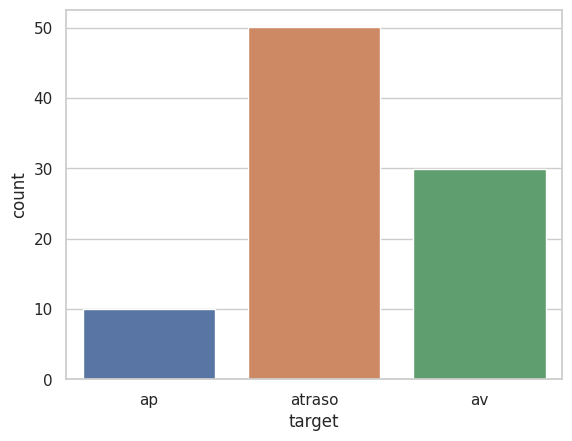

In [126]:
df_target_cleaned = prop(regroup(df_cleaned, group_cols=["target"]))
sns.barplot(df_target_cleaned, x="target", y="count", hue="target")
plt.show()

[INFO] No grouping columns found. Calculating proportion over the entire DataFrame.


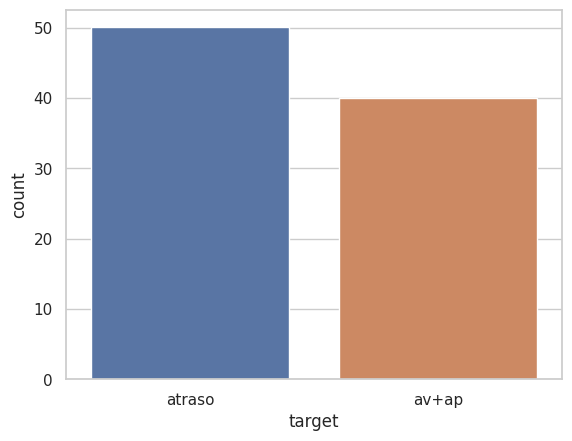

In [128]:
df_target_binary = prop(regroup(df_binary, group_cols=["target"]))
sns.barplot(df_target_binary, x="target", y="count", hue="target")
plt.show()

[INFO] Grouping by: ['anomesdia']


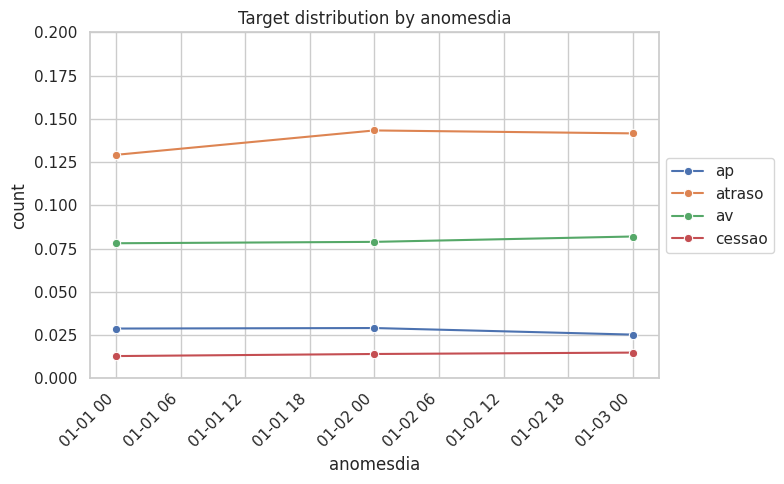

In [287]:
# Target distribution by anomesdia (all)

df_anomesdia_target_all = prop(
    regroup(df_all, group_cols=["anomesdia", "target"])
).sort_values(["anomesdia"], ascending=True)

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))  # you can adjust size if you want

sns.lineplot(
    data=df_anomesdia_target_all.head(12),
    x="anomesdia",
    y="count",
    marker="o",
    hue="target",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.2)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by anomesdia")

plt.tight_layout()
plt.show()

[INFO] Grouping by: ['anomesdia']


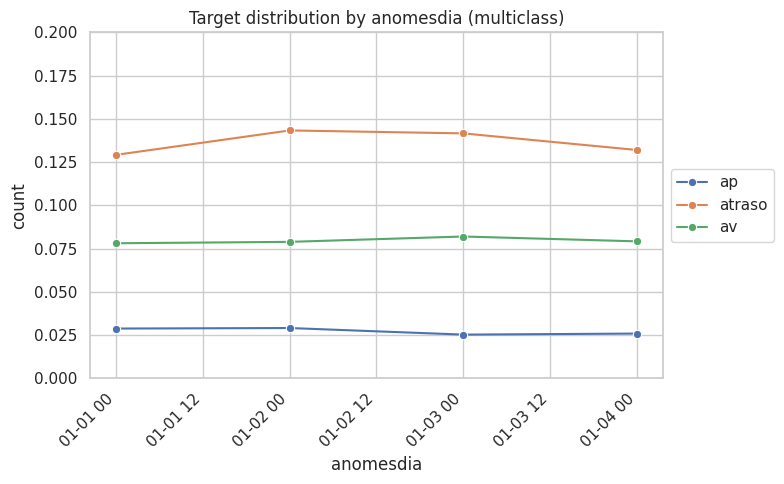

In [288]:
# Target distribution by anomesdia (multilabel)

df_anomesdia_target_multi = prop(
    regroup(df_cleaned, group_cols=["anomesdia", "target"])
).sort_values(["anomesdia"], ascending=True)

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))  # you can adjust size if you want

sns.lineplot(
    data=df_anomesdia_target_multi.head(12),
    x="anomesdia",
    y="count",
    marker="o",
    hue="target",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.2)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by anomesdia (multiclass)")

plt.tight_layout()
plt.show()

[INFO] Grouping by: ['anomesdia']


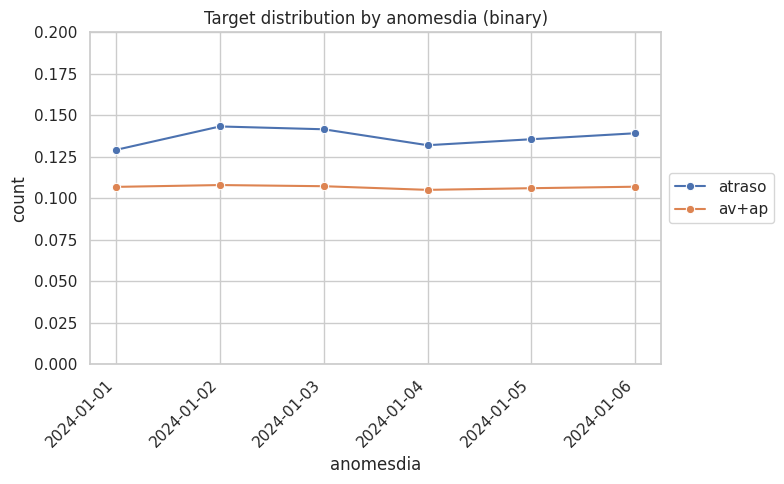

In [286]:
# Target distribution by anomesdia

df_anomesdia_target_binary = prop(
    regroup(df_binary, group_cols=["anomesdia", "target"])
).sort_values(["anomesdia"], ascending=True)

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))  # you can adjust size if you want

sns.lineplot(
    data=df_anomesdia_target_binary.head(12),
    x="anomesdia",
    y="count",
    marker="o",
    hue="target",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.2)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by anomesdia (binary)")

plt.tight_layout()
plt.show()

[INFO] Grouping by: ['produto']


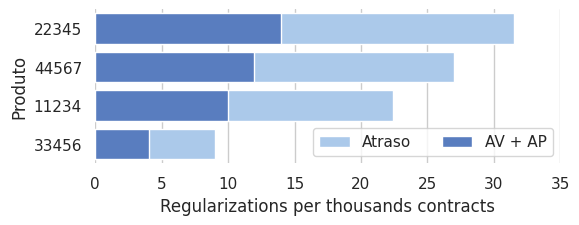

In [278]:
# Target distribution by produto (av + ap)

df_produto_target_binary = prop(regroup(df_binary, group_cols=["produto", "target"]))
df_produto_target_binary_pivot = df_produto_target_binary.pivot(
    index="produto", columns="target", values="count"
)

regu = df_produto_target_binary_pivot.copy()
regu["total"] = regu["atraso"] + regu["av+ap"]
regu = regu.sort_values("total", ascending=False)
# regu[["atraso", "av+ap", "total"]] = regu[["atraso", "av+ap", "total"]] / 10e3

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 2))

# Plot the totals
sns.set_color_codes("pastel")
sns.barplot(x="total", y="produto", data=regu, label="Atraso", color="b")

# Plot the regu
sns.set_color_codes("muted")
sns.barplot(x="av+ap", y="produto", data=regu, label="AV + AP", color="b")

# Add a legend and informative axis label
ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(xlim=(0, 35), ylabel="Produto", xlabel="Regularizations per thousands contracts")
sns.despine(left=True, bottom=True)

[INFO] Grouping by: ['produto']


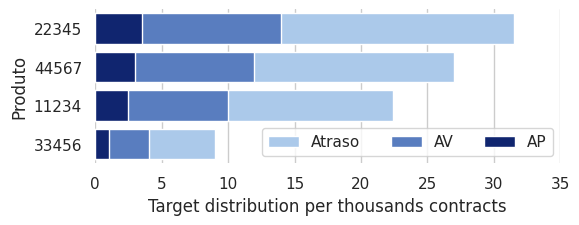

In [277]:
# Target distribution by produto (multilabel)

df_produto_target_multi = prop(regroup(df_cleaned, group_cols=["produto", "target"]))
df_produto_target_multi_pivot = df_produto_target_multi.pivot(
    index="produto", columns="target", values="count"
)

regu = df_produto_target_multi_pivot.copy()

# Calculate the total, av, and ap separately
regu["total"] = regu["atraso"] + regu["av"] + regu["ap"]
regu["av+ap"] = regu["av"] + regu["ap"]
regu = regu.sort_values("total", ascending=False)

# Scale the values for better visualization (in thousands)
# regu[["atraso", "av", "ap", "av+ap", "total"]] = regu[["atraso", "av", "ap", "av+ap", "total"]] / 10e3

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 2))

# Plot the total
sns.set_color_codes("pastel")
sns.barplot(x="total", y="produto", data=regu, label="Atraso", color="b")

# Plot the av as stacked
sns.set_color_codes("muted")
sns.barplot(x="av+ap", y="produto", data=regu, label="AV", color="b")

# Plot the ap as stacked
sns.set_color_codes("dark")
sns.barplot(x="ap", y="produto", data=regu, label="AP", color="b")

# Add a legend and informative axis label
ax.legend(ncol=3, loc="lower right", frameon=True)
ax.set(
    xlim=(0, 35), ylabel="Produto", xlabel="Target distribution per thousands contracts"
)
sns.despine(left=True, bottom=True)

[INFO] Grouping by: ['anomesdia', 'produto']


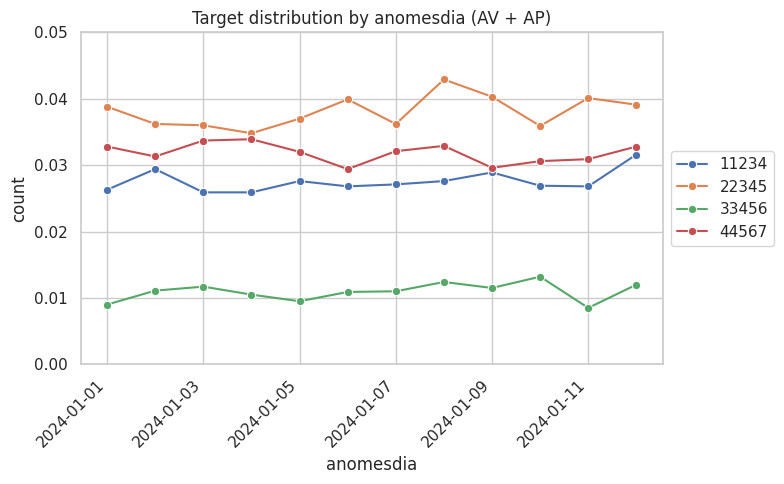

In [242]:
# Target distribution by anomesdia and produto (av + ap)

df_amd_prod_tgt = prop(
    regroup(df_binary, group_cols=["anomesdia", "produto", "target"])
).sort_values(["anomesdia", "produto"], ascending=[True, True])

df_amd_prod_tgt_filtered = df_amd_prod_tgt[df_amd_prod_tgt["target"].isin(["av+ap"])]

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df_amd_prod_tgt_filtered.head(48),
    x="anomesdia",
    y="count",
    marker="o",
    hue="produto",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.05)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by anomesdia (AV + AP)")

plt.tight_layout()
plt.show()

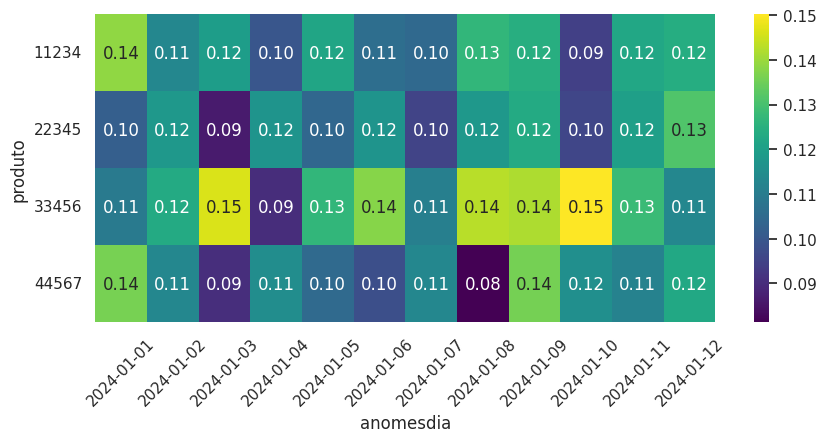

In [237]:
df_amd_prod_filt_pivot = df_amd_prod_tgt_filtered.head(48).pivot(
    index="produto", columns="anomesdia", values="prop"
)

# Create the figure and axis
f, ax = plt.subplots(figsize=(10, 4))  # Customize size if needed

formatted_labels = df_amd_prod_filt_pivot.columns.strftime("%Y-%m-%d")

# Create the heatmap
sns.heatmap(
    df_amd_prod_filt_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=ax,
    xticklabels=formatted_labels,
)

# Make y-axis labels horizontal
ax.yaxis.set_tick_params(rotation=0)

# Optional: rotate x-axis labels for better visibility
ax.xaxis.set_tick_params(rotation=45)

# Show the plot
plt.show()

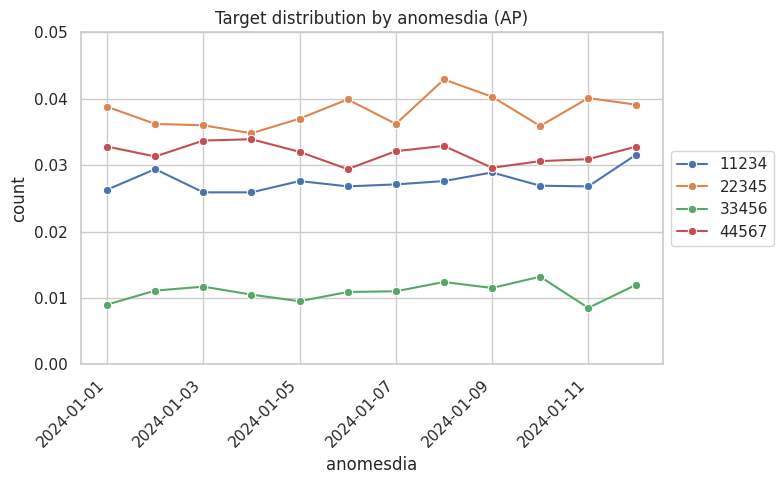

In [ ]:
# Target distribution by anomesdia and produto (ap)

# df_amd_prod_tgt_ap = prop(
#     regroup(df_cleaned, group_cols=["anomesdia", "produto", "target"])
# ).sort_values(["anomesdia", "produto"], ascending=[True, True])

df_amd_prod_tgt_ap_filtered = df_amd_prod_tgt[df_amd_prod_tgt["target"].isin(["ap"])]

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df_amd_prod_tgt_filtered.head(48),
    x="anomesdia",
    y="count",
    marker="o",
    hue="produto",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.05)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by anomesdia (AP)")

plt.tight_layout()
plt.show()

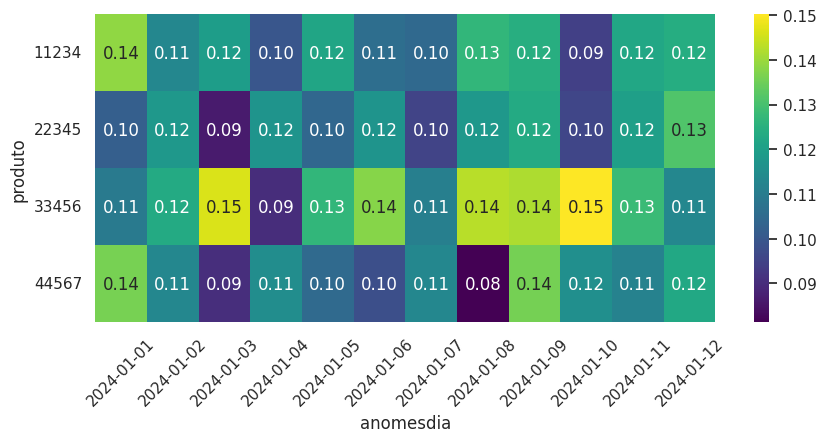

In [239]:
df_amd_prod_ap_filt_pivot = df_amd_prod_tgt_ap_filtered.head(48).pivot(
    index="produto", columns="anomesdia", values="prop"
)

# Create the figure and axis
f, ax = plt.subplots(figsize=(10, 4))  # Customize size if needed

formatted_labels = df_amd_prod_ap_filt_pivot.columns.strftime("%Y-%m-%d")

# Create the heatmap
sns.heatmap(
    df_amd_prod_ap_filt_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=ax,
    xticklabels=formatted_labels,
)

# Make y-axis labels horizontal
ax.yaxis.set_tick_params(rotation=0)

# Optional: rotate x-axis labels for better visibility
ax.xaxis.set_tick_params(rotation=45)

# Show the plot
plt.show()

[INFO] Grouping by: ['produto', 'atraso']


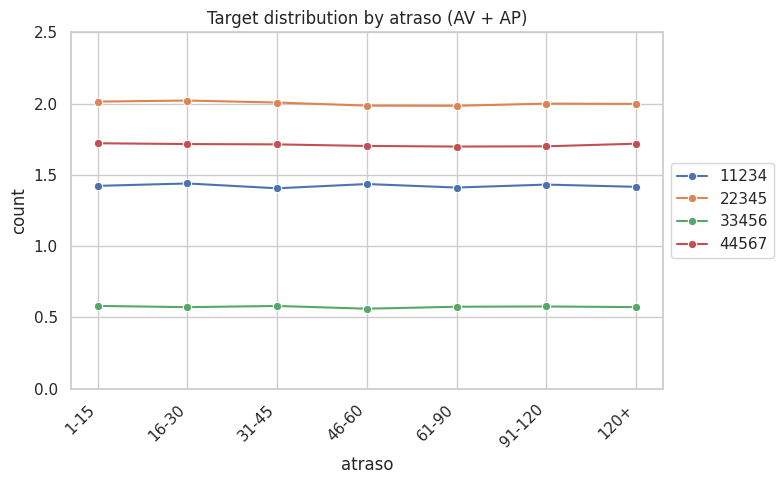

In [265]:
# Target distribution by atraso and produto (av + ap)

df_prod_atrs_tgt = prop(
    regroup(df_binary, group_cols=["produto", "atraso", "target"])
).sort_values(["produto", "atraso"], ascending=[True, True])

df_prod_atrs_tgt_filtered = df_prod_atrs_tgt[df_prod_atrs_tgt["target"].isin(["av+ap"])]

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df_prod_atrs_tgt_filtered,
    x="atraso",
    y="count",
    marker="o",
    hue="produto",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 2.50)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by atraso (AV + AP)")

plt.tight_layout()
plt.show()

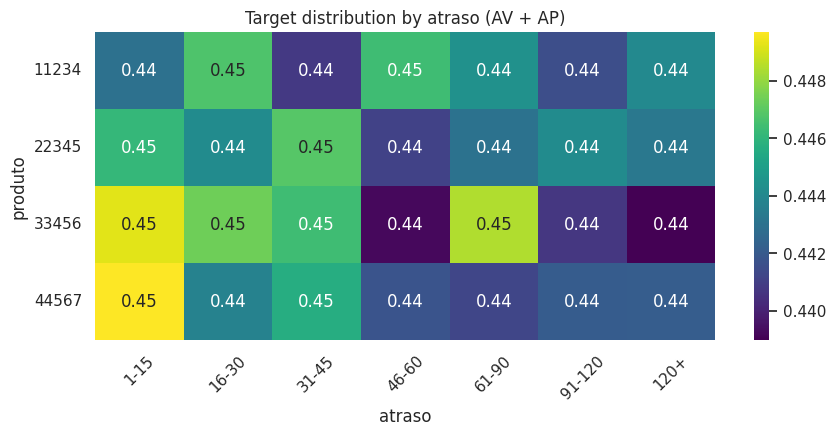

In [273]:
df_prod_atrs_filt_pivot = df_prod_atrs_tgt_filtered.head(48).pivot(
    index="produto", columns="atraso", values="prop"
)

# Create the figure and axis
f, ax = plt.subplots(figsize=(10, 4))  # Customize size if needed

# formatted_labels = df_prod_atrs_filt_pivot.columns.strftime("%Y-%m-%d")

# Create the heatmap
sns.heatmap(
    df_prod_atrs_filt_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=ax,
)

# Make y-axis labels horizontal
ax.yaxis.set_tick_params(rotation=0)

# Optional: rotate x-axis labels for better visibility
ax.xaxis.set_tick_params(rotation=45)

# Set the title
ax.set_title("Target distribution by atraso (AV + AP)")

# Show the plot
plt.show()

[INFO] Grouping by: ['produto', 'atraso']


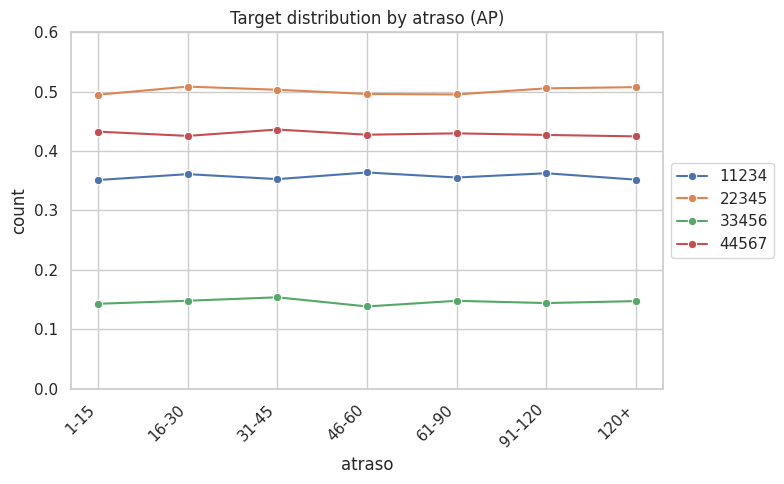

In [ ]:
# Target distribution by atraso and produto (ap)

df_prod_atrs_tgt = prop(
    regroup(df_cleaned, group_cols=["produto", "atraso", "target"])
).sort_values(["produto", "atraso"], ascending=[True, True])

df_prod_atrs_tgt_ap_filtered = df_prod_atrs_tgt[df_prod_atrs_tgt["target"].isin(["ap"])]

# Set whitegrid style
sns.set_style("whitegrid")

# Create figure and axis
f, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df_prod_atrs_tgt_ap_filtered,
    x="atraso",
    y="count",
    marker="o",
    hue="produto",
    ax=ax,
)

# Move legend to the right
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 0.6)

# Rotate x-axis labels properly
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set the title
ax.set_title("Target distribution by atraso (AP)")

plt.tight_layout()
plt.show()

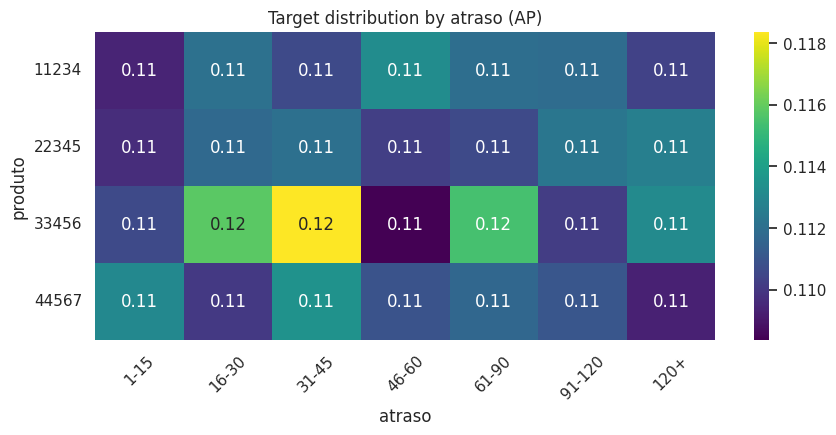

In [275]:
df_prod_atrs_ap_filt_pivot = df_prod_atrs_tgt_ap_filtered.head(48).pivot(
    index="produto", columns="atraso", values="prop"
)

# Create the figure and axis
f, ax = plt.subplots(figsize=(10, 4))  # Customize size if needed

# formatted_labels = df_prod_atrs_ap_filt_pivot.columns.strftime("%Y-%m-%d")

# Create the heatmap
sns.heatmap(
    df_prod_atrs_ap_filt_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=ax,
)

# Make y-axis labels horizontal
ax.yaxis.set_tick_params(rotation=0)

# Optional: rotate x-axis labels for better visibility
ax.xaxis.set_tick_params(rotation=45)

# Set the title
ax.set_title("Target distribution by atraso (AP)")

# Show the plot
plt.show()

[INFO] Grouping by: ['anomesdia', 'produto', 'atraso']


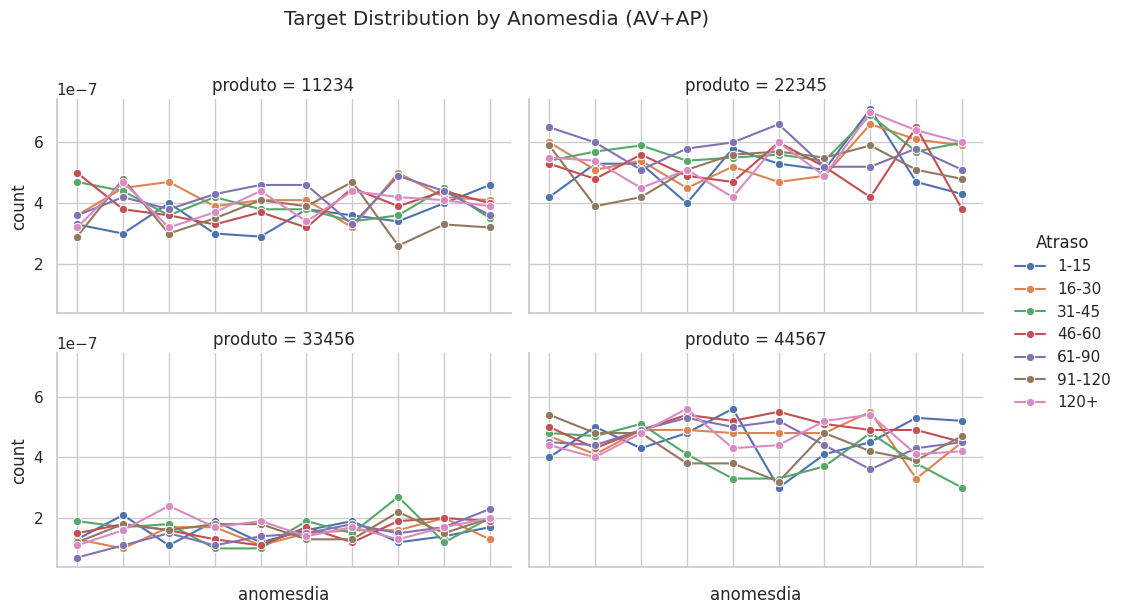

In [311]:
# Calculate proportions
df_grouped = prop(
    regroup(df_binary, group_cols=["anomesdia", "produto", "atraso", "target"])
).sort_values(["anomesdia", "produto", "atraso"], ascending=[True, True, True])

# Filter target
df_filtered = df_grouped[df_grouped["target"] == "av+ap"].sort_values(
    ["anomesdia", "produto", "atraso"], ascending=[True, True, True]
).head(280)

# Create FacetGrid with proper data handling
g = sns.FacetGrid(df_filtered, col="produto", col_wrap=2, height=3, aspect=1.5)

# Use map_dataframe instead of map to ensure data is passed correctly
g.map_dataframe(
    sns.lineplot,  # Plotting function
    x="anomesdia",  # Explicit x-axis
    y="count",  # Explicit y-axis
    hue="atraso",  # Explicit hue variable
    marker="o",
    estimator=None,  # Disable aggregation
)

# Rest of the formatting remains the same
g.add_legend(title="Atraso", loc="center left", bbox_to_anchor=(1, 0.5))
# g.set(ylim=(0, 1))
g.set_xticklabels(rotation=45, ha="right")
g.figure.suptitle("Target Distribution by Anomesdia (AV+AP)", y=1.02)
plt.tight_layout()
plt.show()